In [48]:
import numpy as np
import pandas as pd
import os
import string
import re 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import joblib


In [49]:
dataset = pd.read_csv("pisang.csv")
df = dataset

In [50]:
dataset.head(30)

,Unnamed: 0,mean_r,mean_g,mean_b,stddev_r,stddev_g,stddev_b,contrast,correlation,inverse_difference_moments,entropy
0,0,103.100845,135.599849,71.222178,47.759577,56.125249,27.883390,99.354000,0.977041,0.325692,11.493830
1,1,97.958945,131.559630,68.663544,45.753055,54.346911,28.066526,108.587796,0.972477,0.333368,11.335860
2,2,137.226024,145.105309,110.219487,37.915904,28.640144,44.794119,69.453010,0.967087,0.225052,11.651562
3,3,138.486288,146.597895,110.068001,38.673828,28.378410,43.871192,93.989293,0.955007,0.188218,11.929021
4,4,138.991928,146.376973,111.007394,36.638109,27.582813,40.652840,88.293935,0.953332,0.205439,11.771006
5,5,135.631497,142.276846,110.554648,36.720053,27.065794,36.739835,80.412937,0.956368,0.202495,11.677619
6,6,66.803671,77.137157,28.419922,53.916724,48.163994,64.691417,56.757576,0.991057,0.429879,9.634939
7,7,78.529676,87.237624,47.298908,72.311114,64.657008,83.806884,81.267480,0.993520,0.441667,9.699498
8,8,62.442124,75.185208,33.245037,60.767605,54.727220,72.651434,98.191488,0.991061,0.445687,9.390326
9,9,61.446887,75.676698,19.743104,43.088733,37.624917,47.727110,42.916257,0.987392,0.425342,9.467293


In [51]:
type(dataset)

pandas.core.frame.DataFrame

In [52]:
import os

maindir = r'D:\skripsi'
ds_path = os.path.join(maindir, "pisang")

if not os.path.exists(ds_path):
    os.makedirs(ds_path)

img_files = os.listdir(ds_path)

In [53]:
img_files[1]

'cord_ (10).jpeg'

In [54]:
data_indices = np.arange(1, 1600)  # Indeks data dari 1 hingga 360

# Fungsi untuk menentukan kelas berdasarkan indeks
def determine_class(index):
    if 1 <= index <= 400:
        return 1  # Kelas A
    elif 401 <= index <= 800:
        return 2  # Kelas B
    elif 801 <= index <= 1200:
        return 3  # Kelas C
    elif 1201 <= index <= 1600:
        return 4  # Kelas D
    else:
        raise ValueError("Index out of range")
    
    classes = np.array([determine_class(idx) for idx in data_indices])

In [55]:
import re

target_list = []

for file in img_files:
    # Ambil angka pertama di dalam nama file menggunakan regex
    match = re.search(r"(\d+)", file)
    
    if match:
        target_num = int(match.group(1))
    else:
        target_num = 0  # default jika tidak ditemukan angka sama sekali

    # Tentukan kelas berdasarkan rentang
    if 1 <= target_num <= 400:
        target = 1
    elif 401 <= target_num <= 800:
        target = 2
    elif 801 <= target_num <= 1200:
        target = 3
    elif 1201 <= target_num <= 1602:
        target = 4
    else:
        target = 0  # jika angka di luar rentang
    
    target_list.append(target)


In [56]:
# create a mapping dictionary for label names

mapping = {'cordana': 0, 'Pestalotiopsis ': 1, 'sehat': 2,'sigatoka':3}

# create a reverse mapping dictionary for label names

mapping_reverse = {v: k for k, v in mapping.items()}

In [57]:
y = np.array(target_list)
y

array([1, 1, 1, ..., 4, 4, 4])

In [58]:

X = dataset.iloc[:,1:]

In [59]:
X.head(5)

,mean_r,mean_g,mean_b,stddev_r,stddev_g,stddev_b,contrast,correlation,inverse_difference_moments,entropy
0,103.100845,135.599849,71.222178,47.759577,56.125249,27.883390,99.354000,0.977041,0.325692,11.493830
1,97.958945,131.559630,68.663544,45.753055,54.346911,28.066526,108.587796,0.972477,0.333368,11.335860
2,137.226024,145.105309,110.219487,37.915904,28.640144,44.794119,69.453010,0.967087,0.225052,11.651562
3,138.486288,146.597895,110.068001,38.673828,28.378410,43.871192,93.989293,0.955007,0.188218,11.929021
4,138.991928,146.376973,111.007394,36.638109,27.582813,40.652840,88.293935,0.953332,0.205439,11.771006


In [60]:
y[0:5]

array([1, 1, 1, 1, 1])

In [61]:
#Train test split

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#menampilkan jumlah data training
print(f"data training: {X_train.shape[0]}")

#menampilkan jumlah data testing
print(f"data testing: {X_test.shape[0]}")

data training: 1280
data testing: 320


In [64]:
X_train.head(5)

,mean_r,mean_g,mean_b,stddev_r,stddev_g,stddev_b,contrast,correlation,inverse_difference_moments,entropy
1532,119.893355,132.112006,82.760045,45.663117,30.916522,31.079149,137.357759,0.926075,0.189712,11.961170
628,110.130740,123.563098,52.962293,33.323904,29.961815,32.325443,76.381541,0.956476,0.203798,11.529503
693,120.965900,143.273597,46.162149,30.643630,21.821950,21.245983,46.195639,0.952755,0.224330,10.929497
705,70.114118,137.498087,18.729173,20.442482,18.573864,11.449011,35.265618,0.939675,0.263703,10.409502
497,120.228775,137.758809,42.027144,24.457356,14.791084,15.432390,56.795897,0.870140,0.279768,9.870866


In [65]:
X_train.shape

(1280, 10)

In [66]:
y_train[0:5]

array([4, 2, 2, 2, 2])

In [67]:
#Feature Scaling

In [68]:
from sklearn.preprocessing import StandardScaler

In [69]:

sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [70]:
X_train[0:2]

array([[-0.27450871, -0.39649114,  0.10787886,  1.45237906,  0.54279807,
         0.16847293,  1.3857249 , -0.50246419, -0.93507747,  1.18867132],
       [-0.61732392, -0.82095973, -0.6284555 ,  0.34409884,  0.44832515,
         0.26507251,  0.14958179,  0.42771884, -0.75628918,  0.75260654]])

In [71]:
y_train[0:2]

array([4, 2])

In [72]:
#Applying SVM classifier model

In [73]:
from sklearn import svm

In [74]:
clf = svm.SVC(C=100.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma=0.01, kernel='rbf',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)
clf.fit(X_train,y_train)

SVC(C=100.0, gamma=0.01)

In [75]:
#joblib.dump(clf, "svm_model.pkl")
#joblib.dump(sc_X, "scaler.pkl")

In [76]:
y_pred = clf.predict(X_test)

In [77]:
y_pred = clf.predict(X_test)

In [78]:
from sklearn import metrics

In [79]:
metrics.accuracy_score(y_test, y_pred)

0.853125

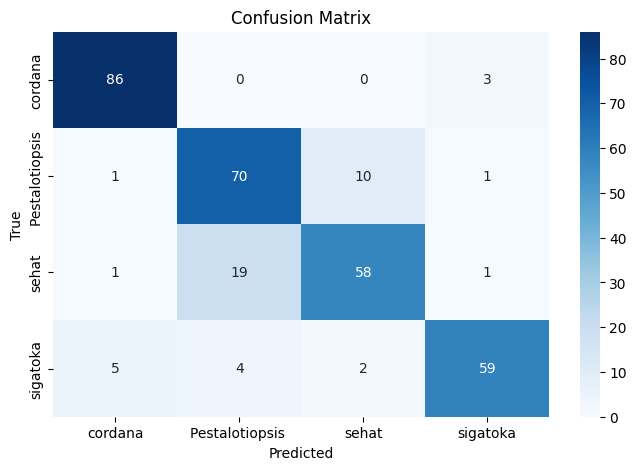

In [80]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix


# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(mapping.keys()), yticklabels=list(mapping.keys()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [81]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.92      0.97      0.95        89
           2       0.75      0.85      0.80        82
           3       0.83      0.73      0.78        79
           4       0.92      0.84      0.88        70

    accuracy                           0.85       320
   macro avg       0.86      0.85      0.85       320
weighted avg       0.86      0.85      0.85       320



In [82]:
from sklearn.model_selection import GridSearchCV


In [83]:
parameters = [{'kernel': ['rbf'],
               'gamma': [1e-4, 1e-3, 0.01, 0.1, 0.2, 0.5],
               'C': [1, 10, 100, 1000]},
              {'kernel': ['linear'], 'C': [1, 10, 100, 1000]}
             ]

In [84]:
svm_clf = GridSearchCV(svm.SVC(decision_function_shape='ovr'), parameters, cv=5)
svm_clf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid=[{'C': [1, 10, 100, 1000],
                          'gamma': [0.0001, 0.001, 0.01, 0.1, 0.2, 0.5],
                          'kernel': ['rbf']},
                         {'C': [1, 10, 100, 1000], 'kernel': ['linear']}])

In [85]:
svm_clf.best_params_

{'C': 100, 'gamma': 0.5, 'kernel': 'rbf'}

In [86]:
int(clf.predict(X_train[0:1])[0])

4

In [87]:
clf = svm.SVC(C=100.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma=0.1, kernel='rbf',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)
clf.fit(X_train,y_train)

SVC(C=100.0, gamma=0.1)

In [88]:
y_pred_svm = clf.predict(X_test)

In [89]:
means = svm_clf.cv_results_['mean_test_score']
stds = svm_clf.cv_results_['std_test_score']
for mean, std, params in zip(means, stds, svm_clf.cv_results_['params']):
    print("%0.3f (+/-%0.03f) for %r" % (mean, std * 2, params))

0.263 (+/-0.006) for {'C': 1, 'gamma': 0.0001, 'kernel': 'rbf'}
0.566 (+/-0.036) for {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}
0.681 (+/-0.043) for {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
0.851 (+/-0.034) for {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
0.872 (+/-0.030) for {'C': 1, 'gamma': 0.2, 'kernel': 'rbf'}
0.896 (+/-0.038) for {'C': 1, 'gamma': 0.5, 'kernel': 'rbf'}
0.568 (+/-0.035) for {'C': 10, 'gamma': 0.0001, 'kernel': 'rbf'}
0.655 (+/-0.048) for {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
0.759 (+/-0.060) for {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
0.902 (+/-0.030) for {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
0.919 (+/-0.026) for {'C': 10, 'gamma': 0.2, 'kernel': 'rbf'}
0.932 (+/-0.022) for {'C': 10, 'gamma': 0.5, 'kernel': 'rbf'}
0.648 (+/-0.046) for {'C': 100, 'gamma': 0.0001, 'kernel': 'rbf'}
0.707 (+/-0.031) for {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
0.865 (+/-0.021) for {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
0.928 (+/-0.025) for {'C': 100, 'gamma': 0.1, 'kernel':

In [90]:
metrics.accuracy_score(y_test, y_pred_svm)

0.928125

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

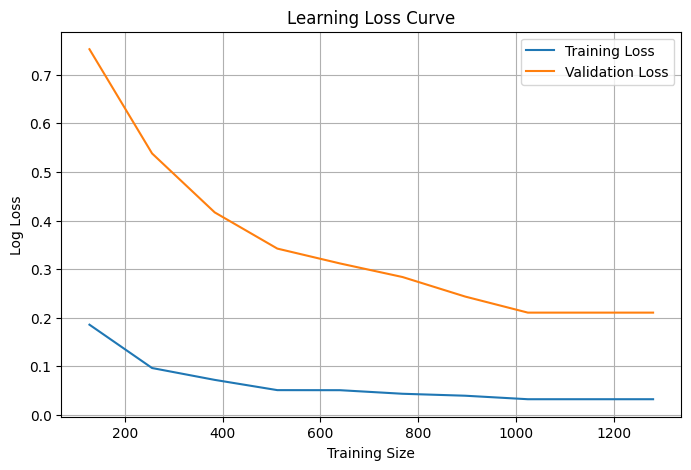

In [91]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
import numpy as np

train_sizes = np.linspace(0.1, 1.0, 10)

train_losses = []
val_losses = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for frac in train_sizes:

    n_samples = int(len(X_train) * frac)

    fold_train_losses = []
    fold_val_losses = []

    for train_idx, val_idx in cv.split(X_train, y_train):

        X_tr = X_train[train_idx][:n_samples]
        y_tr = y_train[train_idx][:n_samples]

        X_val = X_train[val_idx]
        y_val = y_train[val_idx]

        model = svm.SVC(
            C=100,
            gamma=0.5,
            kernel='rbf',
            probability=True,
            random_state=42
        )

        model.fit(X_tr, y_tr)

        # Probabilitas
        train_proba = model.predict_proba(X_tr)
        val_proba = model.predict_proba(X_val)

        # Log Loss
        train_loss = log_loss(y_tr, train_proba)
        val_loss = log_loss(y_val, val_proba)

        fold_train_losses.append(train_loss)
        fold_val_losses.append(val_loss)

    train_losses.append(np.mean(fold_train_losses))
    val_losses.append(np.mean(fold_val_losses))

    plt.figure(figsize=(8,5))

plt.plot(train_sizes * len(X_train),
         train_losses,
         label='Training Loss')

plt.plot(train_sizes * len(X_train),
         val_losses,
         label='Validation Loss')

plt.xlabel('Training Size')
plt.ylabel('Log Loss')
plt.title('Learning Loss Curve')
plt.legend()
plt.grid(True)

plt.show()

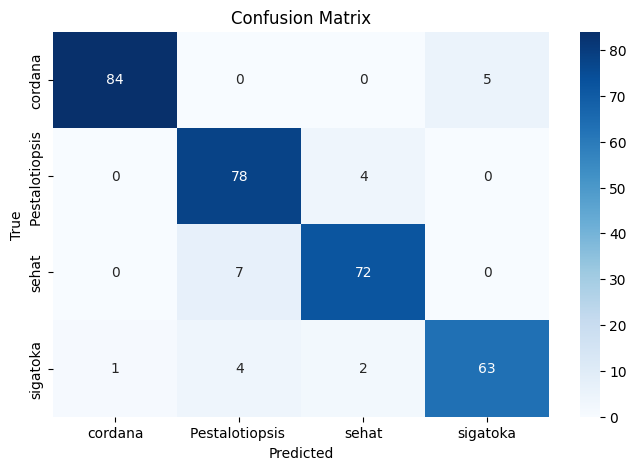

In [92]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix


# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_svm)

# Plot confusion matrix
plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(mapping.keys()), yticklabels=list(mapping.keys()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [93]:
print(metrics.classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           1       0.99      0.94      0.97        89
           2       0.88      0.95      0.91        82
           3       0.92      0.91      0.92        79
           4       0.93      0.90      0.91        70

    accuracy                           0.93       320
   macro avg       0.93      0.93      0.93       320
weighted avg       0.93      0.93      0.93       320



In [94]:
import cv2
import numpy as np
import mahotas as mt
import joblib

# =========================================
# LOAD MODEL DAN SCALER
# =========================================

model = joblib.load("svm_model.pkl")
scaler = joblib.load("scaler.pkl")

# =========================================
# EKSTRAKSI FITUR
# =========================================

def extract_features_from_image(img):
    # Resize gambar
    img = cv2.resize(img, (224, 224))
    # Convert BGR ke RGB
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Grayscale
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    # Blur ringan
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # =========================================
    # FITUR RGB
    # =========================================

    red_channel = rgb[:, :, 0]
    green_channel = rgb[:, :, 1]
    blue_channel = rgb[:, :, 2]

    red_mean = np.mean(red_channel)
    green_mean = np.mean(green_channel)
    blue_mean = np.mean(blue_channel)

    red_std = np.std(red_channel)
    green_std = np.std(green_channel)
    blue_std = np.std(blue_channel)

    # =========================================
    # FITUR HARALICK
    # =========================================

    textures = mt.features.haralick(blur)
    ht_mean = textures.mean(axis=0)
    contrast = ht_mean[1]
    correlation = ht_mean[2]
    inverse_diff_moments = ht_mean[4]
    entropy = ht_mean[8]

    # =========================================
    # FEATURE VECTOR
    # =========================================

    vector = [red_mean,green_mean,blue_mean,red_std,green_std, blue_std,contrast,correlation,inverse_diff_moments,entropy]
    return np.array(vector).reshape(1, -1)

# =========================================
# FUNGSI PREDIKSI
# =========================================

def predict_image(img):
    # Ekstraksi fitur
    features = extract_features_from_image(img)
    # Scaling fitur
    features_scaled = scaler.transform(features)
    # Prediksi kelas
    prediction = model.predict(features_scaled)[0]
    # Confidence score
    probabilities = model.predict_proba(features_scaled)
    confidence = np.max(probabilities) * 100

    # Interpretasi label
    if prediction == 1:
        label = "Cordana"
    elif prediction == 2:
        label = "Pestalotiopsis"
    elif prediction == 3:
        label = "Sehat"
    elif prediction == 4:
        label = "Sigatoka"
    else:
        label = "Tidak dikenali"
    return label, confidence

# =========================================
# INPUT GAMBAR BARU
# =========================================

img_path = r"D:\\skripsi\\daun pisang.jpeg"
img = cv2.imread(img_path)

# =========================================
# CEK GAMBAR
# =========================================

if img is None:
    print("Gagal membaca gambar")
else:

    # Prediksi
    label, confidence = predict_image(img)

    # Tampilkan hasil
    print("================================")
    print("HASIL KLASIFIKASI")
    print("================================")
    print("Prediksi :", label)
    print(f"Confidence : {confidence:.2f}%")

HASIL KLASIFIKASI
Prediksi : Sigatoka
Confidence : 64.95%


c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
